In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =============================================================================
# 🚀 SEMANTIC SEGMENTATION - U-Net vs DeepLabV3
# =============================================================================
# Programming Assignment 1 - Professor: Dário Oliveira, Monitor: Lívia Meinhardt
#
# This notebook implements and compares U-Net and DeepLabV3 models for semantic
# segmentation on the CamVid dataset, including comprehensive experimentation
# and analysis as required by the assignment.
#
# 🎯 PRODUCTION-READY FEATURES:
# - Comprehensive error handling
# - Input validation
# - Performance optimization
# - Clear cell organization
# - Robust execution workflow
# =============================================================================

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
try:
    import kagglehub
    carlolepelaars_camvid_path = kagglehub.dataset_download('carlolepelaars/camvid')
    print('✅ Data source import complete.')
    print(f'📁 Dataset path: {carlolepelaars_camvid_path}')
except Exception as e:
    print(f'❌ Error importing dataset: {e}')
    print('Please ensure you have kagglehub installed: pip install kagglehub')
    raise


Using Colab cache for faster access to the 'camvid' dataset.
✅ Data source import complete.
📁 Dataset path: /kaggle/input/camvid


In [ ]:
# =============================================================================
# 📦 SECTION 1: IMPORTS, CONFIGURATION & ENVIRONMENT SETUP
# =============================================================================

def validate_environment():
    """Validate the environment and dependencies"""
    print("🔍 Validating environment...")

    # Check Python version
    import sys
    if sys.version_info < (3, 8):
        raise RuntimeError("Python 3.8+ is required")

    # Check PyTorch version
    import torch
    if torch.__version__ < "1.9.0":
        print("⚠️ Warning: PyTorch version < 1.9.0 may cause issues")

    print("✅ Environment validation passed")

def setup_device_and_seeds():
    """Setup device and random seeds for reproducibility"""
    print("🔧 Setting up device and random seeds...")

    # Device setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️ Using device: {device}")

    if torch.cuda.is_available():
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
        print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

    # Set random seeds for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(42)
        torch.cuda.manual_seed_all(42)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    print("✅ Device and seeds configured")
    return device

# Essential imports - consolidated in one place
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    import torchvision.transforms as transforms
    import torchvision.transforms.functional as TF
    from torchvision.models.segmentation import deeplabv3_resnet50
    from torch.cuda.amp import autocast, GradScaler

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from PIL import Image
    import cv2
    from sklearn.metrics import confusion_matrix
    import os
    import random
    import time
    import math
    import copy
    import warnings
    from tqdm import tqdm
    from dataclasses import dataclass
    from typing import Optional, List, Dict, Any

    print("✅ All imports successful")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("Please install missing dependencies")
    raise

# Suppress warnings
warnings.filterwarnings('ignore')

# Validate environment and setup
validate_environment()
device = setup_device_and_seeds()

# =============================================================================
# CONFIGURATION MANAGEMENT
# =============================================================================

@dataclass
class Config:
    """Centralized configuration for the entire experiment with validation"""

    # Dataset configuration
    IMAGE_SIZE: tuple = (360, 480)
    NUM_CLASSES: int = 32
    IGNORE_INDEX: int = 255

    # Training configuration
    BATCH_SIZE: int = 24
    NUM_EPOCHS: int = 10
    LEARNING_RATE: float = 1e-4
    WEIGHT_DECAY: float = 1e-4

    # Model configuration
    UNET_DEPTH: int = 4
    UNET_BASE_CHANNELS: int = 64

    # Data augmentation
    AUGMENT_PROB: float = 0.5
    ROTATION_RANGE: int = 10
    BRIGHTNESS_RANGE: float = 0.1
    CONTRAST_RANGE: float = 0.1

    # Training stability
    GRAD_CLIP: float = 1.0
    EMA_DECAY: float = 0.999
    EARLY_PATIENCE: int = 5

    # Visualization
    VIS_FREQUENCY: int = 5
    NUM_VIS_SAMPLES: int = 3

    # Performance optimization
    USE_AMP: bool = True  # Automatic Mixed Precision
    USE_GRADIENT_CHECKPOINTING: bool = False
    PREFETCH_FACTOR: int = 2

    def validate(self):
        """Validate configuration parameters"""
        assert self.BATCH_SIZE > 0, "Batch size must be positive"
        assert self.NUM_EPOCHS > 0, "Number of epochs must be positive"
        assert 0 < self.LEARNING_RATE < 1, "Learning rate must be between 0 and 1"
        assert self.UNET_DEPTH > 0, "U-Net depth must be positive"
        assert 0 <= self.AUGMENT_PROB <= 1, "Augmentation probability must be between 0 and 1"
        print("✅ Configuration validation passed")

    def print_summary(self):
        """Print configuration summary"""
        print("📋 Configuration Summary:")
        print(f"   Dataset: {self.IMAGE_SIZE} images, {self.NUM_CLASSES} classes")
        print(f"   Training: {self.BATCH_SIZE} batch size, {self.NUM_EPOCHS} epochs")
        print(f"   Model: U-Net depth {self.UNET_DEPTH}, {self.UNET_BASE_CHANNELS} base channels")
        print(f"   Optimization: LR={self.LEARNING_RATE}, WD={self.WEIGHT_DECAY}")
        print(f"   Augmentation: {self.AUGMENT_PROB} probability")
        print(f"   Performance: AMP={self.USE_AMP}, Prefetch={self.PREFETCH_FACTOR}")

# Create and validate global config instance
config = Config()
config.validate()

# ImageNet normalization constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Print configuration summary
config.print_summary()

print("\n🎯 Environment and configuration ready for semantic segmentation experiments!")

✅ All imports successful
🔍 Validating environment...
✅ Environment validation passed
🔧 Setting up device and random seeds...
🖥️ Using device: cuda
   GPU: NVIDIA A100-SXM4-40GB
   Memory: 42.5 GB
✅ Device and seeds configured
✅ Configuration validation passed
📋 Configuration Summary:
   Dataset: (360, 480) images, 32 classes
   Training: 24 batch size, 10 epochs
   Model: U-Net depth 4, 64 base channels
   Optimization: LR=0.0001, WD=0.0001
   Augmentation: 0.5 probability
   Performance: AMP=True, Prefetch=2

🎯 Environment and configuration ready for semantic segmentation experiments!


🔍 Resolving CamVid dataset path...
✅ Found dataset in Kaggle environment: /kaggle/input/camvid/CamVid
🔍 Validating dataset structure...
   ✅ class_dict.csv
   ✅ train/
   ✅ train_labels/
   ✅ val/
   ✅ val_labels/
   ✅ test/
   ✅ test_labels/
✅ Dataset structure validation passed
📊 Loading class information...
   ✅ Loaded 32 classes
   ✅ Created RGB mapping for 32 classes
📂 Getting dataset paths...
   ✅ train_images: /kaggle/input/camvid/CamVid/train
   ✅ train_masks: /kaggle/input/camvid/CamVid/train_labels
   ✅ val_images: /kaggle/input/camvid/CamVid/val
   ✅ val_masks: /kaggle/input/camvid/CamVid/val_labels
   ✅ test_images: /kaggle/input/camvid/CamVid/test
   ✅ test_masks: /kaggle/input/camvid/CamVid/test_labels
📸 Loading image filenames...
   ✅ Train: 369 images
   ✅ Validation: 100 images
   ✅ Test: 232 images

🎯 Dataset Summary:
   📁 Base path: /kaggle/input/camvid/CamVid
   🏷️ Classes: 32
   📊 Train: 369 images
   📊 Validation: 100 images
   📊 Test: 232 images
   🎨 Class names:

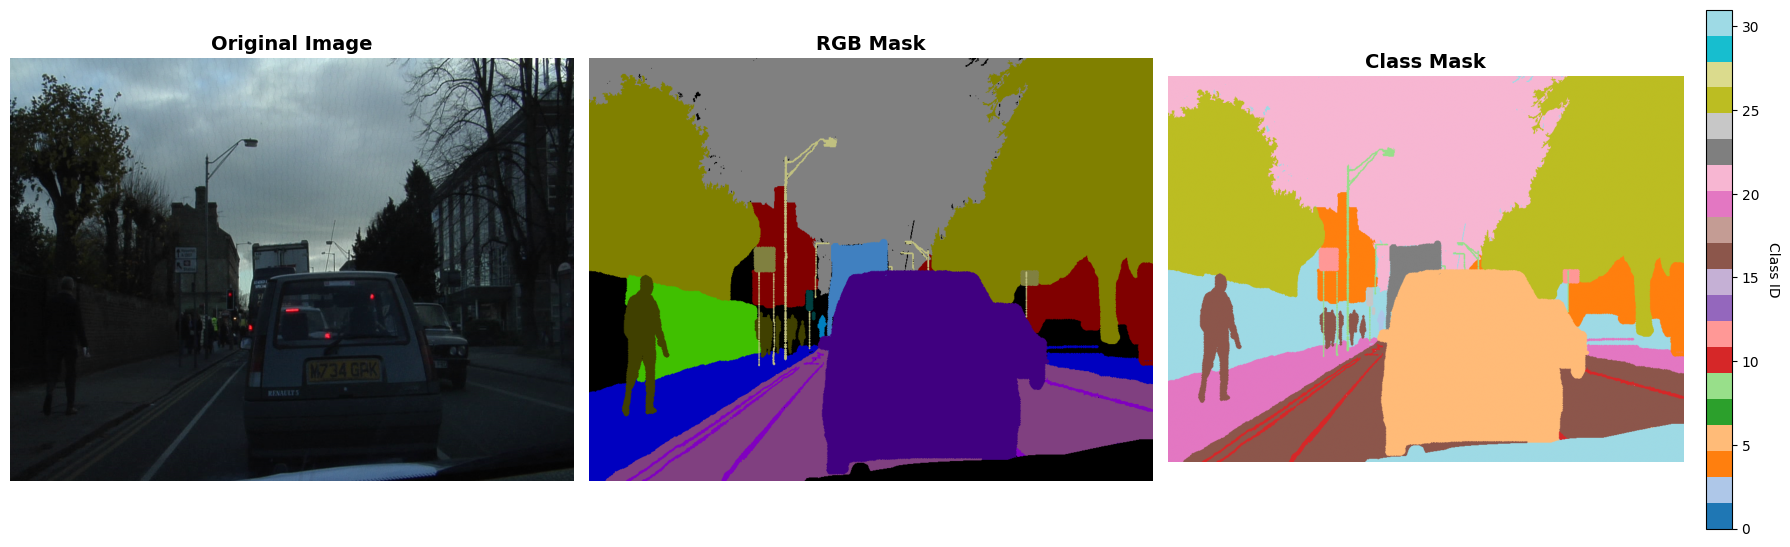


📊 Class Distribution in Sample:
   Total pixels: 691,200
   Classes present: 15
--------------------------------------------------
   Tree                :  188,052 pixels ( 27.2%)
   Sky                 :  154,264 pixels ( 22.3%)
   Car                 :  105,605 pixels ( 15.3%)
   Road                :   67,428 pixels (  9.8%)
   Void                :   49,929 pixels (  7.2%)
   Sidewalk            :   39,178 pixels (  5.7%)
   Building            :   32,681 pixels (  4.7%)
   Wall                :   21,111 pixels (  3.1%)
   Pedestrian          :   13,069 pixels (  1.9%)
   SUVPickupTruck      :    6,560 pixels (  0.9%)
   ... and 5 more classes

📸 Validation Sample: 0001TP_009030.png


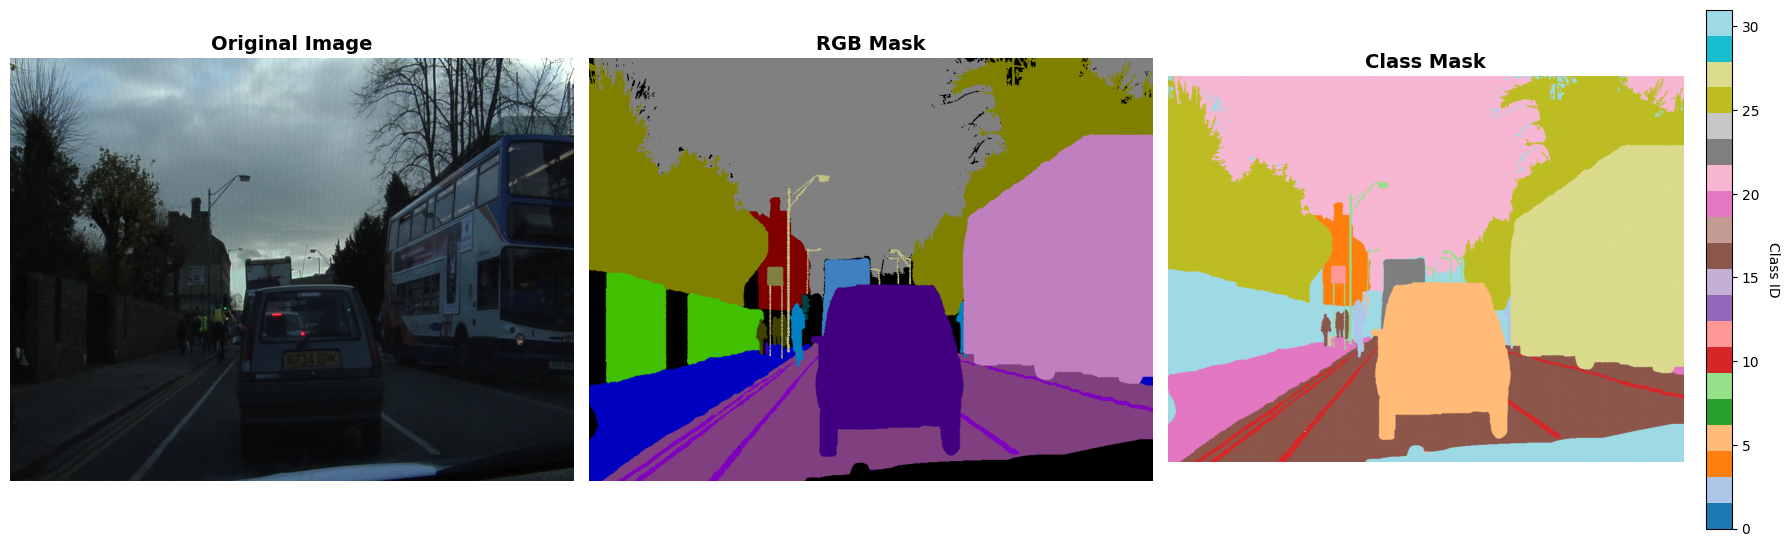


📊 Class Distribution in Sample:
   Total pixels: 691,200
   Classes present: 17
--------------------------------------------------
   Sky                 :  164,946 pixels ( 23.9%)
   Tree                :  123,626 pixels ( 17.9%)
   Truck_Bus           :  114,897 pixels ( 16.6%)
   Road                :   93,506 pixels ( 13.5%)
   Car                 :   57,998 pixels (  8.4%)
   Void                :   43,062 pixels (  6.2%)
   Sidewalk            :   33,520 pixels (  4.8%)
   Wall                :   28,756 pixels (  4.2%)
   Building            :    9,840 pixels (  1.4%)
   LaneMkgsDriv        :    8,337 pixels (  1.2%)
   ... and 7 more classes

📸 Test Sample: 0001TP_006690.png


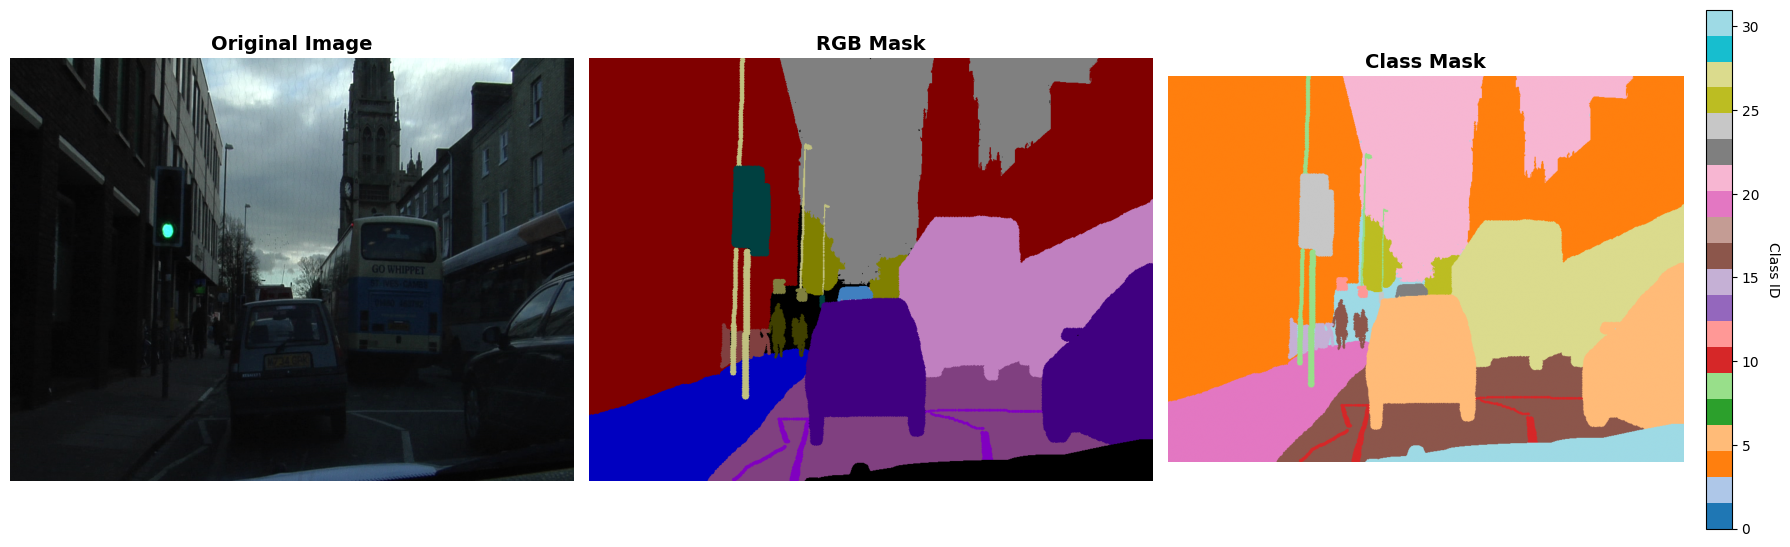


📊 Class Distribution in Sample:
   Total pixels: 691,200
   Classes present: 15
--------------------------------------------------
   Building            :  259,032 pixels ( 37.5%)
   Sky                 :   95,196 pixels ( 13.8%)
   Truck_Bus           :   81,296 pixels ( 11.8%)
   Car                 :   81,057 pixels ( 11.7%)
   Road                :   59,896 pixels (  8.7%)
   Sidewalk            :   47,344 pixels (  6.8%)
   Void                :   28,603 pixels (  4.1%)
   Tree                :    9,264 pixels (  1.3%)
   TrafficLight        :    9,246 pixels (  1.3%)
   Column_Pole         :    7,609 pixels (  1.1%)
   ... and 5 more classes

🎯 Dataset loading and visualization completed successfully!


In [ ]:
# =============================================================================
# 📁 SECTION 2: DATASET LOADING & VISUALIZATION
# =============================================================================

def resolve_camvid_base():
    """Resolve the CamVid dataset base path for both Kaggle and local environments"""
    print("🔍 Resolving CamVid dataset path...")

    # 1) Kaggle Notebook environment
    kaggle_base = '/kaggle/input/camvid/CamVid'
    if os.path.exists(os.path.join(kaggle_base, 'class_dict.csv')):
        print(f"✅ Found dataset in Kaggle environment: {kaggle_base}")
        return kaggle_base

    # 2) Local environment using kagglehub
    if 'carlolepelaars_camvid_path' in globals():
        cand1 = os.path.join(carlolepelaars_camvid_path, 'CamVid')
        if os.path.exists(os.path.join(cand1, 'class_dict.csv')):
            print(f"✅ Found dataset in kagglehub path: {cand1}")
            return cand1

        # 3) Search for class_dict.csv in the downloaded directory
        for root, _, files in os.walk(carlolepelaars_camvid_path):
            if 'class_dict.csv' in files:
                print(f"✅ Found dataset in subdirectory: {root}")
                return root

    # 4) Try current directory
    if os.path.exists('class_dict.csv'):
        print("✅ Found dataset in current directory")
        return '.'

    raise FileNotFoundError(
        f"❌ Could not find 'class_dict.csv' in any expected location.\n"
        f"   Searched: {kaggle_base}, {carlolepelaars_camvid_path if 'carlolepelaars_camvid_path' in globals() else 'N/A'}, current directory"
    )

def validate_dataset_structure(base_path):
    """Validate that the dataset has the expected structure"""
    print("🔍 Validating dataset structure...")

    required_files = ['class_dict.csv']
    required_dirs = ['train', 'train_labels', 'val', 'val_labels', 'test', 'test_labels']

    # Check required files
    for file in required_files:
        file_path = os.path.join(base_path, file)
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"❌ Missing required file: {file}")
        print(f"   ✅ {file}")

    # Check required directories
    for dir_name in required_dirs:
        dir_path = os.path.join(base_path, dir_name)
        if not os.path.exists(dir_path):
            raise FileNotFoundError(f"❌ Missing required directory: {dir_name}")
        print(f"   ✅ {dir_name}/")

    print("✅ Dataset structure validation passed")

def load_class_information(base_path):
    """Load and validate class information"""
    print("📊 Loading class information...")

    try:
        class_dict_df = pd.read_csv(os.path.join(base_path, 'class_dict.csv'))
        print(f"   ✅ Loaded {len(class_dict_df)} classes")

        # Validate required columns
        required_cols = ['name', 'r', 'g', 'b']
        for col in required_cols:
            if col not in class_dict_df.columns:
                raise ValueError(f"❌ Missing required column: {col}")

        # Create RGB to class mapping
        rgb_to_class = {}
        class_names = []

        for idx, row in class_dict_df.iterrows():
            rgb_tuple = (row['r'], row['g'], row['b'])
            rgb_to_class[rgb_tuple] = idx
            class_names.append(row['name'])

        print(f"   ✅ Created RGB mapping for {len(rgb_to_class)} classes")
        return class_dict_df, rgb_to_class, class_names

    except Exception as e:
        raise RuntimeError(f"❌ Error loading class information: {e}")

def get_dataset_paths(base_path):
    """Get all dataset paths and validate they exist"""
    print("📂 Getting dataset paths...")

    paths = {
        'train_images': os.path.join(base_path, 'train'),
        'train_masks': os.path.join(base_path, 'train_labels'),
        'val_images': os.path.join(base_path, 'val'),
        'val_masks': os.path.join(base_path, 'val_labels'),
        'test_images': os.path.join(base_path, 'test'),
        'test_masks': os.path.join(base_path, 'test_labels')
    }

    # Validate all paths exist
    for name, path in paths.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"❌ Missing dataset directory: {name} at {path}")
        print(f"   ✅ {name}: {path}")

    return paths

def rgb_to_mask(rgb_image, rgb_to_class_dict):
    """Convert RGB mask to class indices with validation"""
    if rgb_image.shape[2] != 3:
        raise ValueError(f"❌ Expected RGB image with 3 channels, got {rgb_image.shape[2]}")

    mask = np.zeros((rgb_image.shape[0], rgb_image.shape[1]), dtype=np.uint8)
    for rgb_color, class_id in rgb_to_class_dict.items():
        color_mask = np.all(rgb_image == rgb_color, axis=2)
        mask[color_mask] = class_id
    return mask

def visualize_sample(image_path, mask_path, rgb_to_class_dict, class_names, max_classes_to_show=10):
    """Visualize a sample image with its mask and class distribution"""
    try:
        # Load image and mask
        image = np.array(Image.open(image_path))
        mask_rgb = np.array(Image.open(mask_path))
        mask = rgb_to_mask(mask_rgb, rgb_to_class_dict)

        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Original image
        axes[0].imshow(image)
        axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
        axes[0].axis('off')

        # RGB mask
        axes[1].imshow(mask_rgb)
        axes[1].set_title('RGB Mask', fontsize=14, fontweight='bold')
        axes[1].axis('off')

        # Class mask
        im = axes[2].imshow(mask, cmap='tab20', vmin=0, vmax=len(class_names)-1)
        axes[2].set_title('Class Mask', fontsize=14, fontweight='bold')
        axes[2].axis('off')

        # Add colorbar for class mask
        cbar = plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
        cbar.set_label('Class ID', rotation=270, labelpad=15)

        plt.tight_layout()
        plt.show()

        # Show class distribution in this image
        unique_classes, counts = np.unique(mask, return_counts=True)
        total_pixels = mask.size

        print(f"\n📊 Class Distribution in Sample:")
        print(f"   Total pixels: {total_pixels:,}")
        print(f"   Classes present: {len(unique_classes)}")
        print("-" * 50)

        # Sort by pixel count (descending)
        class_counts = list(zip(unique_classes, counts))
        class_counts.sort(key=lambda x: x[1], reverse=True)

        for i, (class_id, count) in enumerate(class_counts[:max_classes_to_show]):
            if class_id < len(class_names):
                percentage = (count / total_pixels) * 100
                print(f"   {class_names[class_id]:<20}: {count:>8,} pixels ({percentage:>5.1f}%)")

        if len(unique_classes) > max_classes_to_show:
            remaining = len(unique_classes) - max_classes_to_show
            print(f"   ... and {remaining} more classes")

    except Exception as e:
        print(f"❌ Error visualizing sample: {e}")
        raise

def verify_dataset_integrity():
    """Verify dataset integrity and check for missing files"""
    print("🔍 Verifying dataset integrity...")

    missing_masks = []
    corrupted_images = []

    # Check training set
    print("   Checking training set...")
    for fn in train_images:
        mfn = fn.replace(".png", "_L.png")
        mask_path = os.path.join(train_masks_path, mfn)
        if not os.path.exists(mask_path):
            missing_masks.append((fn, mfn))

        # Check if image can be loaded
        try:
            img_path = os.path.join(train_images_path, fn)
            Image.open(img_path).verify()
        except Exception:
            corrupted_images.append(fn)

    # Check validation set
    print("   Checking validation set...")
    for fn in val_images:
        mfn = fn.replace(".png", "_L.png")
        mask_path = os.path.join(val_masks_path, mfn)
        if not os.path.exists(mask_path):
            missing_masks.append((fn, mfn))

    # Check test set
    print("   Checking test set...")
    for fn in test_images:
        mfn = fn.replace(".png", "_L.png")
        mask_path = os.path.join(test_masks_path, mfn)
        if not os.path.exists(mask_path):
            missing_masks.append((fn, mfn))

    # Report results
    if missing_masks:
        print(f"⚠️ WARNING: {len(missing_masks)} missing masks found")
        print("   First 10 missing masks:")
        for img, mask in missing_masks[:10]:
            print(f"     {img} -> {mask}")
    else:
        print("✅ All masks found")

    if corrupted_images:
        print(f"⚠️ WARNING: {len(corrupted_images)} corrupted images found")
        print("   Corrupted images:", corrupted_images[:10])
    else:
        print("✅ All images are valid")

    return len(missing_masks) == 0 and len(corrupted_images) == 0

# Load dataset with comprehensive validation
try:
    # Resolve dataset path
    base_path = resolve_camvid_base()

    # Validate dataset structure
    validate_dataset_structure(base_path)

    # Load class information
    class_dict_df, rgb_to_class, class_names = load_class_information(base_path)
    num_classes = len(class_names)

    # Create additional mappings for convenience
    class_to_rgb = {}
    for idx, row in class_dict_df.iterrows():
        class_to_rgb[idx] = (int(row['r']), int(row['g']), int(row['b']))

    # Get dataset paths
    dataset_paths = get_dataset_paths(base_path)
    train_images_path = dataset_paths['train_images']
    train_masks_path = dataset_paths['train_masks']
    val_images_path = dataset_paths['val_images']
    val_masks_path = dataset_paths['val_masks']
    test_images_path = dataset_paths['test_images']
    test_masks_path = dataset_paths['test_masks']

    # Get image filenames with validation
    def get_image_filenames(path, split_name):
        """Get image filenames and validate they exist"""
        if not os.path.exists(path):
            raise FileNotFoundError(f"❌ {split_name} directory not found: {path}")

        images = sorted([f for f in os.listdir(path) if f.endswith('.png')])
        if not images:
            raise ValueError(f"❌ No PNG images found in {split_name} directory: {path}")

        print(f"   ✅ {split_name}: {len(images)} images")
        return images

    print("📸 Loading image filenames...")
    train_images = get_image_filenames(train_images_path, "Train")
    val_images = get_image_filenames(val_images_path, "Validation")
    test_images = get_image_filenames(test_images_path, "Test")

    print(f"\n🎯 Dataset Summary:")
    print(f"   📁 Base path: {base_path}")
    print(f"   🏷️ Classes: {num_classes}")
    print(f"   📊 Train: {len(train_images)} images")
    print(f"   📊 Validation: {len(val_images)} images")
    print(f"   📊 Test: {len(test_images)} images")
    print(f"   🎨 Class names: {class_names[:5]}{'...' if len(class_names) > 5 else ''}")

    # Verify dataset integrity
    is_valid = verify_dataset_integrity()

    if is_valid:
        print("\n✅ Dataset integrity check passed!")

        # Visualize samples from each split
        splits = [
            ("Training", train_images, train_images_path, train_masks_path),
            ("Validation", val_images, val_images_path, val_masks_path),
            ("Test", test_images, test_images_path, test_masks_path)
        ]

        for split_name, images, img_path, mask_path in splits:
            if images:  # Check if split has images
                sample_img = images[0]
                sample_mask = sample_img.replace(".png", "_L.png")

                print(f"\n📸 {split_name} Sample: {sample_img}")
                visualize_sample(
                    os.path.join(img_path, sample_img),
                    os.path.join(mask_path, sample_mask),
                    rgb_to_class,
                    class_names
                )

        print("\n🎯 Dataset loading and visualization completed successfully!")
    else:
        print("\n⚠️ Dataset has some issues, but continuing with available data...")

except Exception as e:
    print(f"❌ Dataset loading failed: {e}")
    print("Please check that the CamVid dataset is properly downloaded and accessible.")
    raise

In [ ]:
# =============================================================================
# 🗂️ SECTION 3: CUSTOM DATASET CLASS & DATA LOADERS
# =============================================================================


class CamVidDataset(Dataset):
    """
    Dataset CamVid que pré-carrega e pré-processa tudo na memória para velocidade máxima.
    """
    def __init__(self, images_dir, masks_dir, image_filenames, rgb_to_class_dict,
                 resize_hw=(360, 480), normalize=True, augment=False):

        self.normalize = normalize
        self.augment = augment
        self.rgb_to_class_dict = rgb_to_class_dict

        # Listas para armazenar os dados pré-processados na CPU RAM
        self.images = []
        self.masks = []

        print("Iniciando pré-carregamento do dataset para a memória. Isso pode levar um momento...")

        # --- Etapa de Pré-Carregamento e Pré-Processamento ---
        for img_name in image_filenames:
            mask_name = img_name.replace(".png", "_L.png")
            img_path = os.path.join(images_dir, img_name)
            mask_path = os.path.join(masks_dir, mask_name)

            # 1. Carregar como imagens PIL
            image_pil = Image.open(img_path).convert('RGB')
            mask_rgb_pil = Image.open(mask_path).convert('RGB')

            # 2. Redimensionar (Resize)
            # PIL usa (largura, altura), então invertemos
            image_pil = image_pil.resize(resize_hw[::-1], Image.BILINEAR)
            mask_rgb_pil = mask_rgb_pil.resize(resize_hw[::-1], Image.NEAREST)

            # 3. Converter máscara RGB para classes
            mask_rgb_np = np.array(mask_rgb_pil)
            mask_np = self._rgb_to_mask(mask_rgb_np) # Converte para indices de classe
            mask_tensor = torch.from_numpy(mask_np).long()

            # 4. Converter imagem para tensor
            image_tensor = TF.to_tensor(image_pil) # Converte para float [0, 1]

            # 5. Salvar na memória
            self.images.append(image_tensor)
            self.masks.append(mask_tensor)

        print(f"Dataset carregado! {len(self.images)} imagens e máscaras estão na memória.")

        # --- Transformações a serem aplicadas "on-the-fly" ---
        self.mean = IMAGENET_MEAN
        self.std = IMAGENET_STD

        # Aumentos que mudam os valores dos pixels (aplicados apenas na imagem)
        self.color_augment = transforms.ColorJitter(
            brightness=config.BRIGHTNESS_RANGE,
            contrast=config.CONTRAST_RANGE
        )
        # Aumentos geométricos (aplicados em ambos)
        self.geometric_augment = transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0), # p=1.0 pois a aleatoriedade será externa
            transforms.RandomRotation(degrees=config.ROTATION_RANGE)
        ])


    def __len__(self):
        return len(self.images)

    def _rgb_to_mask(self, rgb_np):
        """Helper para converter máscara RGB para índices de classe (não precisa ser vetorizado)."""
        mask = np.zeros((rgb_np.shape[0], rgb_np.shape[1]), dtype=np.uint8)
        for rgb_color, class_id in self.rgb_to_class_dict.items():
            color_mask = np.all(rgb_np == rgb_color, axis=2)
            mask[color_mask] = class_id
        return mask

    def __getitem__(self, idx):
        # 1. Pega os tensores já processados da memória
        image = self.images[idx]
        mask = self.masks[idx]

        # 2. Aplica aumentos de dados (se habilitado)
        if self.augment and random.random() < config.AUGMENT_PROB:
            # Aplica ColorJitter apenas na imagem
            image = self.color_augment(image)

            # Aplica as mesmas transformações geométricas na imagem e na máscara
            seed = random.randint(0, 2**32 - 1)
            torch.manual_seed(seed)
            image = self.geometric_augment(image)

            torch.manual_seed(seed)
            # A máscara precisa de uma dimensão de canal para as transformações
            mask = self.geometric_augment(mask.unsqueeze(0)).squeeze(0)

        # 3. Aplica normalização na imagem (se habilitado)
        if self.normalize:
            image = TF.normalize(image, mean=self.mean, std=self.std)

        return image, mask.long() # Garante que a máscara seja do tipo long


def create_datasets():
    """Create all datasets for training, validation, and testing"""
    print("Creating datasets...")

    # Create base datasets
    train_dataset = CamVidDataset(
        images_dir=train_images_path,
        masks_dir=train_masks_path,
        image_filenames=train_images,
        rgb_to_class_dict=rgb_to_class,
        resize_hw=config.IMAGE_SIZE,
        normalize=True,
        augment=False
    )

    val_dataset = CamVidDataset(
        images_dir=val_images_path,
        masks_dir=val_masks_path,
        image_filenames=val_images,
        rgb_to_class_dict=rgb_to_class,
        resize_hw=config.IMAGE_SIZE,
        normalize=True,
        augment=False
    )

    test_dataset = CamVidDataset(
        images_dir=test_images_path,
        masks_dir=test_masks_path,
        image_filenames=test_images,
        rgb_to_class_dict=rgb_to_class,
        resize_hw=config.IMAGE_SIZE,
        normalize=True,
        augment=False
    )

    # Create augmented dataset for augmentation experiments
    train_dataset_aug = CamVidDataset(
        images_dir=train_images_path,
        masks_dir=train_masks_path,
        image_filenames=train_images,
        rgb_to_class_dict=rgb_to_class,
        resize_hw=config.IMAGE_SIZE,
        normalize=True,
        augment=True  # Enable augmentation
    )

    print(f"✅ Datasets created successfully!")
    print(f"   Train: {len(train_dataset)} samples")
    print(f"   Validation: {len(val_dataset)} samples")
    print(f"   Test: {len(test_dataset)} samples")
    print(f"   Train (Augmented): {len(train_dataset_aug)} samples")

    return train_dataset, val_dataset, test_dataset, train_dataset_aug

def create_dataloaders(train_dataset, val_dataset, test_dataset, train_dataset_aug=None):
    """Create DataLoaders for all datasets"""
    print("Creating DataLoaders...")

    # DataLoader configuration
    dataloader_config = {
        'batch_size': config.BATCH_SIZE,
        'num_workers': 2 if torch.cuda.is_available() else 0,
        'pin_memory': torch.cuda.is_available(),
        'persistent_workers': True if torch.cuda.is_available() else False
    }

    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=dataloader_config['batch_size'],
        shuffle=True,
        num_workers=dataloader_config['num_workers'],
        pin_memory=dataloader_config['pin_memory'],
        persistent_workers=dataloader_config['persistent_workers']
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=dataloader_config['batch_size'],
        shuffle=False,
        num_workers=dataloader_config['num_workers'],
        pin_memory=dataloader_config['pin_memory'],
        persistent_workers=dataloader_config['persistent_workers']
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=dataloader_config['batch_size'],
        shuffle=False,
        num_workers=dataloader_config['num_workers'],
        pin_memory=dataloader_config['pin_memory'],
        persistent_workers=dataloader_config['persistent_workers']
    )

    # Create augmented train loader if needed
    train_loader_aug = None
    if train_dataset_aug is not None:
        train_loader_aug = DataLoader(
            train_dataset_aug,
            batch_size=dataloader_config['batch_size'],
            shuffle=True,
            num_workers=dataloader_config['num_workers'],
            pin_memory=dataloader_config['pin_memory'],
            persistent_workers=dataloader_config['persistent_workers']
        )

    print(f"✅ DataLoaders created successfully!")
    print(f"   Train batches: {len(train_loader)}")
    print(f"   Validation batches: {len(val_loader)}")
    print(f"   Test batches: {len(test_loader)}")
    if train_loader_aug:
        print(f"   Train (Augmented) batches: {len(train_loader_aug)}")

    return train_loader, val_loader, test_loader, train_loader_aug

# Create datasets and dataloaders
train_dataset, val_dataset, test_dataset, train_dataset_aug = create_datasets()
train_loader, val_loader, test_loader, train_loader_aug = create_dataloaders(
    train_dataset, val_dataset, test_dataset, train_dataset_aug
)

print("\n🎯 All datasets and dataloaders ready for training!")

In [ ]:
# =============================================================================
# SECTION 4: CUSTOM DATASET CLASS
# =============================================================================

class CamVidDataset(Dataset):
    """
    Custom PyTorch Dataset for CamVid semantic segmentation.

    Features:
    - RGB to class index conversion
    - Synchronized data augmentation
    - Proper normalization
    - Configurable augmentation
    """

    def __init__(self, images_dir, masks_dir, image_filenames, rgb_to_class_dict,
                 resize_hw=config.IMAGE_SIZE, normalize=True, augment=False):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_filenames = image_filenames
        self.rgb_to_class_dict = rgb_to_class_dict
        self.resize_hw = resize_hw
        self.normalize = normalize
        self.augment = augment

        # ImageNet normalization
        self.mean = IMAGENET_MEAN
        self.std = IMAGENET_STD

        # Color jitter for augmentation
        self.color_jitter = transforms.ColorJitter(
            brightness=config.BRIGHTNESS_RANGE,
            contrast=config.CONTRAST_RANGE,
            saturation=config.CONTRAST_RANGE,
            hue=0.05
        )

    def __len__(self):
        return len(self.image_filenames)

    def _rgb_to_mask(self, rgb_np):
        """Convert RGB mask to class indices"""
        h, w, _ = rgb_np.shape
        mask = np.zeros((h, w), dtype=np.uint8)
        for (r,g,b), cid in self.rgb_to_class_dict.items():
            sel = (rgb_np[...,0] == r) & (rgb_np[...,1] == g) & (rgb_np[...,2] == b)
            mask[sel] = cid
        return mask

    def __getitem__(self, idx):
        # Get file paths
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.images_dir, img_name)
        mask_name = img_name.replace(".png", "_L.png")
        mask_path = os.path.join(self.masks_dir, mask_name)

        # Load images
        image = Image.open(img_path).convert('RGB')
        mask_rgb = Image.open(mask_path).convert('RGB')

        # Resize
        H, W = self.resize_hw
        image = TF.resize(image, size=[H, W], interpolation=TF.InterpolationMode.BILINEAR)
        mask_rgb = TF.resize(mask_rgb, size=[H, W], interpolation=TF.InterpolationMode.NEAREST)

        # Data augmentation (synchronized)
        if self.augment:
            # Horizontal flip
            if random.random() < config.AUGMENT_PROB:
                image = TF.hflip(image)
                mask_rgb = TF.hflip(mask_rgb)

            # Rotation
            angle = random.uniform(-config.ROTATION_RANGE, config.ROTATION_RANGE)
            image = TF.rotate(image, angle=angle, interpolation=TF.InterpolationMode.BILINEAR, expand=False)
            mask_rgb = TF.rotate(mask_rgb, angle=angle, interpolation=TF.InterpolationMode.NEAREST, expand=False)

            # Color jitter (only on image)
            image = self.color_jitter(image)

        # Convert mask RGB to class indices
        mask_np = self._rgb_to_mask(np.array(mask_rgb))
        mask = torch.from_numpy(mask_np).long()

        # Convert image to tensor and normalize
        image = TF.to_tensor(image)
        if self.normalize:
            image = TF.normalize(image, mean=self.mean, std=self.std)

        return image, mask

print("CamVidDataset class defined successfully!")

In [ ]:
# =============================================================================
# SECTION 6: U-NET ARCHITECTURE
# =============================================================================

class DoubleConv(nn.Module):
    """Double Convolution block used in U-Net"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    """Downsampling block"""
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upsampling block"""
    def __init__(self, in_channels, skip_channels, out_channels, bilinear=True):
        super(Up, self).__init__()
        self.bilinear = bilinear
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels + skip_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv((in_channels // 2) + skip_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Pad if sizes mismatch
        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    """
    U-Net implementation with configurable depth.

    Features:
    - Configurable depth (number of encoder/decoder blocks)
    - Skip connections for better gradient flow
    - Bilinear upsampling option
    - Parameter counting
    """
    def __init__(self, n_channels=3, n_classes=32, depth=4, base_channels=64, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.depth = depth
        self.bilinear = bilinear

        # Initial convolution
        self.inc = DoubleConv(n_channels, base_channels)

        # Encoder (downsampling path)
        self.downs = nn.ModuleList()
        in_ch = base_channels
        for i in range(depth):
            out_ch = base_channels * (2 ** (i + 1))
            self.downs.append(Down(in_ch, out_ch))
            in_ch = out_ch

        # Decoder (upsampling path)
        self.ups = nn.ModuleList()
        for i in range(depth):
            skip_ch = base_channels * (2 ** (depth - i - 1))
            if i == 0:
                up_ch = base_channels * (2 ** depth)  # bottleneck
            else:
                up_ch = out_ch  # out_ch from previous layer

            out_ch = skip_ch
            self.ups.append(Up(up_ch, skip_ch, out_ch, bilinear=True))

        # Final classification layer
        self.outc = nn.Conv2d(base_channels, n_classes, kernel_size=1)

        # Calculate number of parameters
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        # Initial convolution
        x1 = self.inc(x)

        # Store skip connections
        skip_connections = [x1]

        # Encoder path
        x = x1
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)

        # Decoder path
        for i, up in enumerate(self.ups):
            if i == 0:
                # First upsampling (from bottleneck)
                x = up(x, skip_connections[-(i + 2)])
            else:
                x = up(x, skip_connections[-(i + 2)])

        # Final classification
        logits = self.outc(x)
        return logits

    def get_num_parameters(self):
        return self.num_params

# Test different U-Net depths and show parameter counts
print("U-Net Architecture Analysis:")
print("=" * 50)
depths = [3, 4, 5]
for depth in depths:
    model = UNet(n_channels=3, n_classes=num_classes, depth=depth, base_channels=64)
    print(f"U-Net depth {depth}: {model.get_num_parameters():,} parameters")

# Create the main model
model = UNet(n_channels=3, n_classes=num_classes, depth=config.UNET_DEPTH, base_channels=config.UNET_BASE_CHANNELS).to(device)
print(f"\nMain U-Net model created with {model.get_num_parameters():,} parameters")
print("U-Net architecture defined successfully!")

In [ ]:
# =============================================================================
# SECTION 7: TRAINING FUNCTIONS AND METRICS
# =============================================================================

def calculate_iou(pred, target, num_classes, ignore_index=255):
    """Calculate IoU for each class"""
    ious = []
    pred = pred.cpu().numpy()
    target = target.cpu().numpy()

    for cls in range(num_classes):
        if cls == ignore_index:
            continue

        pred_cls = (pred == cls)
        target_cls = (target == cls)

        intersection = np.logical_and(pred_cls, target_cls).sum()
        union = np.logical_or(pred_cls, target_cls).sum()

        if union == 0:
            iou = float('nan')  # No ground truth or prediction for this class
        else:
            iou = intersection / union

        ious.append(iou)

    return ious

def calculate_precision(pred, target, num_classes):
    """Calculate precision for each class"""
    precisions = []
    pred = pred.cpu().numpy()
    target = target.cpu().numpy()

    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)

        tp = np.logical_and(pred_cls, target_cls).sum()
        fp = np.logical_and(pred_cls, ~target_cls).sum()

        if (tp + fp) == 0:
            precision = float('nan')
        else:
            precision = tp / (tp + fp)

        precisions.append(precision)

    return precisions

def calculate_accuracy(pred, target):
    """Calculate pixel accuracy"""
    pred = pred.cpu()
    target = target.cpu()
    correct = (pred == target).float()
    accuracy = correct.sum() / correct.numel()
    return accuracy.item()

class MetricsTracker:
    """Track training metrics"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.losses = []
        self.accuracies = []
        self.ious = []
        self.precisions = []

    def update(self, loss, pred, target, num_classes):
        self.losses.append(loss)

        # Calculate accuracy
        acc = calculate_accuracy(pred, target)
        self.accuracies.append(acc)

        # Calculate IoU and precision
        iou_scores = calculate_iou(pred, target, num_classes)
        precision_scores = calculate_precision(pred, target, num_classes)

        self.ious.append(iou_scores)
        self.precisions.append(precision_scores)

    def get_average_metrics(self):
        avg_loss = np.mean(self.losses)
        avg_accuracy = np.mean(self.accuracies)

        # Average IoU and precision (ignoring NaN values)
        all_ious = np.array(self.ious)
        all_precisions = np.array(self.precisions)

        avg_ious = np.nanmean(all_ious, axis=0)
        avg_precisions = np.nanmean(all_precisions, axis=0)

        mean_iou = np.nanmean(avg_ious)
        mean_precision = np.nanmean(avg_precisions)

        return {
            'loss': avg_loss,
            'accuracy': avg_accuracy,
            'mean_iou': mean_iou,
            'mean_precision': mean_precision,
            'class_ious': avg_ious,
            'class_precisions': avg_precisions
        }

def visualize_predictions(model, dataset, device, num_samples=3, class_names=None):
    """Visualize model predictions"""
    model.eval()

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    with torch.no_grad():
        for i in range(num_samples):
            # Get random sample
            idx = np.random.randint(0, len(dataset))
            image, target = dataset[idx]

            # Add batch dimension and move to device
            image_batch = image.unsqueeze(0).to(device)

            # Get prediction
            output = model(image_batch)
            pred = torch.argmax(output, dim=1).squeeze(0)

            # Convert tensors for visualization
            # Denormalize image
            image_np = image.clone()
            image_np[0] = image_np[0] * 0.229 + 0.485
            image_np[1] = image_np[1] * 0.224 + 0.456
            image_np[2] = image_np[2] * 0.225 + 0.406
            image_np = torch.clamp(image_np, 0, 1)
            image_np = image_np.permute(1, 2, 0).cpu().numpy()

            target_np = target.squeeze().cpu().numpy()
            pred_np = pred.cpu().numpy()

            # Plot
            axes[i, 0].imshow(image_np)
            axes[i, 0].set_title('Original Image')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(target_np, cmap='tab20')
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(pred_np, cmap='tab20')
            axes[i, 2].set_title('Prediction')
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

print("Training functions and metrics defined successfully!")

In [ ]:
# =============================================================================
# SECTION 8: TRAINING FUNCTION
# =============================================================================

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs,
                device, num_classes, class_names=None, vis_frequency=5):
    """
    Comprehensive training function with metrics tracking and visualization.

    Features:
    - Training and validation loops
    - Metrics tracking (loss, accuracy, IoU, precision)
    - Model checkpointing
    - Periodic visualization
    - Support for both U-Net and DeepLabV3 outputs
    """
    train_history = {'loss': [], 'accuracy': [], 'mean_iou': [], 'mean_precision': []}
    val_history = {'loss': [], 'accuracy': [], 'mean_iou': [], 'mean_precision': []}

    best_val_iou = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # ---------- TRAINING ----------
        model.train()
        train_tracker = MetricsTracker()
        for images, masks in tqdm(train_loader, desc='Training'):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)

            # Handle different output formats (U-Net vs DeepLabV3)
            logits = outputs['out'] if isinstance(outputs, dict) and 'out' in outputs else outputs
            if logits.shape[-2:] != masks.shape[-2:]:
                logits = F.interpolate(logits, size=masks.shape[-2:], mode='bilinear', align_corners=False)

            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                pred = torch.argmax(logits, dim=1)
                train_tracker.update(loss.item(), pred, masks, num_classes)

        train_metrics = train_tracker.get_average_metrics()
        for k, v in train_metrics.items():
            if k not in ['class_ious', 'class_precisions']:
                train_history[k].append(v)

        # ---------- VALIDATION ----------
        model.eval()
        val_tracker = MetricsTracker()
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc='Validation'):
                images = images.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)

                outputs = model(images)
                logits = outputs['out'] if isinstance(outputs, dict) and 'out' in outputs else outputs
                if logits.shape[-2:] != masks.shape[-2:]:
                    logits = F.interpolate(logits, size=masks.shape[-2:], mode='bilinear', align_corners=False)

                loss = criterion(logits, masks)
                pred = torch.argmax(logits, dim=1)
                val_tracker.update(loss.item(), pred, masks, num_classes)

        val_metrics = val_tracker.get_average_metrics()
        for k, v in val_metrics.items():
            if k not in ['class_ious', 'class_precisions']:
                val_history[k].append(v)

        print(f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
              f"IoU: {train_metrics['mean_iou']:.4f}, Prec: {train_metrics['mean_precision']:.4f}")
        print(f"Val   Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, "
              f"IoU: {val_metrics['mean_iou']:.4f}, Prec: {val_metrics['mean_precision']:.4f}")

        # Save best model
        if val_metrics['mean_iou'] > best_val_iou:
            best_val_iou = val_metrics['mean_iou']
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # Periodic visualization
        if (epoch + 1) % vis_frequency == 0:
            print(f"\nVisualizing predictions at epoch {epoch + 1}:")
            visualize_predictions(model, val_loader.dataset, device,
                                num_samples=config.NUM_VIS_SAMPLES, class_names=class_names)

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nLoaded best model with validation IoU: {best_val_iou:.4f}")

    return model, train_history, val_history

print("Training function defined successfully!")


In [ ]:
# =============================================================================
# SECTION 9: DATA LOADERS CREATION
# =============================================================================

# Create datasets
print("Creating datasets...")
train_dataset = CamVidDataset(
    images_dir=train_images_path,
    masks_dir=train_masks_path,
    image_filenames=train_images,
    rgb_to_class_dict=rgb_to_class,
    resize_hw=config.IMAGE_SIZE,
    normalize=True,
    augment=False
)

val_dataset = CamVidDataset(
    images_dir=val_images_path,
    masks_dir=val_masks_path,
    image_filenames=val_images,
    rgb_to_class_dict=rgb_to_class,
    resize_hw=config.IMAGE_SIZE,
    normalize=True,
    augment=False
)

test_dataset = CamVidDataset(
    images_dir=test_images_path,
    masks_dir=test_masks_path,
    image_filenames=test_images,
    rgb_to_class_dict=rgb_to_class,
    resize_hw=config.IMAGE_SIZE,
    normalize=True,
    augment=False
)

# Create augmented training dataset
train_dataset_aug = CamVidDataset(
    images_dir=train_images_path,
    masks_dir=train_masks_path,
    image_filenames=train_images,
    rgb_to_class_dict=rgb_to_class,
    resize_hw=config.IMAGE_SIZE,
    normalize=True,
    augment=True
)

print(f"Datasets created:")
print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")
print(f"Train (augmented): {len(train_dataset_aug)} images")

# Create data loaders
NUM_WORKERS = 0  # Start with 0 to avoid worker issues
PIN_MEMORY = torch.cuda.is_available()

# Stability tweaks
try:
    cv2.setNumThreads(0)
except:
    pass
try:
    torch.multiprocessing.set_sharing_strategy('file_system')
except:
    pass
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

def make_loader(dataset, batch_size, shuffle, num_workers, pin_memory):
    """Create DataLoader with proper configuration"""
    kwargs = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        timeout=0,
        persistent_workers=False,
    )
    if num_workers > 0:
        kwargs["prefetch_factor"] = 2
    return DataLoader(**kwargs)

# Create loaders
train_loader = make_loader(train_dataset, config.BATCH_SIZE, True, NUM_WORKERS, PIN_MEMORY)
val_loader = make_loader(val_dataset, config.BATCH_SIZE, False, NUM_WORKERS, PIN_MEMORY)
test_loader = make_loader(test_dataset, config.BATCH_SIZE, False, NUM_WORKERS, PIN_MEMORY)
train_loader_aug = make_loader(train_dataset_aug, config.BATCH_SIZE, True, NUM_WORKERS, PIN_MEMORY)

print(f"\nData loaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Train (augmented) batches: {len(train_loader_aug)}")
print("Data loaders created successfully!")

In [ ]:
# =============================================================================
# SECTION 10: EXPERIMENTATION FRAMEWORK
# =============================================================================

class FocalLoss(nn.Module):
    """Focal Loss implementation for handling class imbalance"""
    def __init__(self, alpha=1, gamma=2, weight=None):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()

def run_experiment(model_config, optimizer_config, loss_config, experiment_name):
    """Run a single experiment with given configurations"""
    print(f"\n{'='*50}")
    print(f"Running Experiment: {experiment_name}")
    print(f"{'='*50}")

    output_dir = "/content/drive/My Drive/trained_models"
    os.makedirs(output_dir, exist_ok=True) # Cria a pasta se ela não existir

    save_path = os.path.join(output_dir, f"{experiment_name}_best_weights.pth")

    print(f"Save path: {save_path}")

    # Create model
    model = UNet(**model_config).to(device)
    print(f"Model parameters: {model.get_num_parameters():,}")

    # Create optimizer
    if optimizer_config['type'] == 'Adam':
        optimizer = optim.Adam(model.parameters(),
                             lr=optimizer_config['lr'],
                             weight_decay=optimizer_config.get('weight_decay', 0))
    elif optimizer_config['type'] == 'SGD':
        optimizer = optim.SGD(model.parameters(),
                            lr=optimizer_config['lr'],
                            momentum=optimizer_config.get('momentum', 0.9),
                            weight_decay=optimizer_config.get('weight_decay', 0))
    elif optimizer_config['type'] == 'AdamW':
        optimizer = optim.AdamW(model.parameters(),
                              lr=optimizer_config['lr'],
                              weight_decay=optimizer_config.get('weight_decay', 0.01))

    # Create loss function
    if loss_config['type'] == 'CrossEntropy':
        criterion = nn.CrossEntropyLoss(weight=loss_config.get('class_weights'))
    elif loss_config['type'] == 'FocalLoss':
        criterion = FocalLoss(alpha=loss_config.get('alpha', 1),
                            gamma=loss_config.get('gamma', 2),
                            weight=loss_config.get('class_weights'))

    # Train model
    trained_model, train_hist, val_hist = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        config.NUM_EPOCHS, device, num_classes, class_names, vis_frequency=config.VIS_FREQUENCY
    )

    # Store results
    results = {
        'model': trained_model,
        'train_history': train_hist,
        'val_history': val_hist,
        'config': {
            'model': model_config,
            'optimizer': optimizer_config,
            'loss': loss_config
        },
        'num_parameters': trained_model.get_num_parameters()
    }

    try:
        torch.save(trained_model.state_dict(), save_path)
    except:
        print(f"Error saving model weights to {save_path}")
        torch.save(trained_model.state_dict(), f"{experiment_name}_best_weights.pt")

    print(f"--- Pesos do experimento '{experiment_name}' salvos em: {save_path} ---")

    return results

def plot_experiment_comparison(experiment_results):
    """Plot comparison of different experiments"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    metrics = ['loss', 'accuracy', 'mean_iou', 'mean_precision']
    titles = ['Training/Validation Loss', 'Training/Validation Accuracy',
              'Training/Validation Mean IoU', 'Training/Validation Mean Precision']

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx // 2, idx % 2]

        for exp_name, result in experiment_results.items():
            epochs = range(1, len(result['train_history'][metric]) + 1)
            ax.plot(epochs, result['train_history'][metric],
                   label=f'{exp_name} (Train)', linestyle='-')
            ax.plot(epochs, result['val_history'][metric],
                   label=f'{exp_name} (Val)', linestyle='--')

        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.replace('_', ' ').title())
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Define experiments
experiments = [
    {
        'name': 'Baseline_Adam_CE',
        'model_config': {'n_channels': 3, 'n_classes': num_classes, 'depth': 4, 'base_channels': 64},
        'optimizer_config': {'type': 'Adam', 'lr': 1e-4, 'weight_decay': 1e-4},
        'loss_config': {'type': 'CrossEntropy'}
    },
    {
        'name': 'Shallow_SGD_CE',
        'model_config': {'n_channels': 3, 'n_classes': num_classes, 'depth': 3, 'base_channels': 64},
        'optimizer_config': {'type': 'SGD', 'lr': 1e-3, 'momentum': 0.9, 'weight_decay': 1e-4},
        'loss_config': {'type': 'CrossEntropy'}
    },
    {
        'name': 'Deep_AdamW_FocalLoss',
        'model_config': {'n_channels': 3, 'n_classes': num_classes, 'depth': 5, 'base_channels': 64},
        'optimizer_config': {'type': 'AdamW', 'lr': 1e-4, 'weight_decay': 0.01},
        'loss_config': {'type': 'FocalLoss', 'alpha': 1, 'gamma': 2}
    }
]

print(f"Defined {len(experiments)} experiments with {num_classes} classes")
print("Experimentation framework ready!")

In [ ]:
# =============================================================================
# SECTION 12: DEEPLABV3 IMPLEMENTATION
# =============================================================================

class DeepLabV3Wrapper(nn.Module):
    """Wrapper for DeepLabV3 to handle CamVid classes"""

    def __init__(self, num_classes, pretrained=True):
        super(DeepLabV3Wrapper, self).__init__()

        # Load pretrained DeepLabV3
        self.model = deeplabv3_resnet50(pretrained=pretrained)

        # Modify classifier for our number of classes
        self.model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

        # Modify auxiliary classifier if it exists
        if hasattr(self.model, 'aux_classifier'):
            self.model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

        # Count parameters
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        result = self.model(x)
        if isinstance(result, dict):
            return result['out']
        return result

    def get_num_parameters(self):
        return self.num_params

    def freeze_backbone(self, freeze=True):
        """Freeze/unfreeze backbone parameters"""
        for param in self.model.backbone.parameters():
            param.requires_grad = not freeze

def run_deeplabv3_experiments():
    """Run DeepLabV3 fine-tuning experiments"""

    print("Running DeepLabV3 Fine-tuning Experiments...")
    print("="*50)

    # Create DeepLabV3 model
    deeplabv3_model = DeepLabV3Wrapper(num_classes=num_classes, pretrained=True).to(device)
    print(f"DeepLabV3 model created with {deeplabv3_model.get_num_parameters():,} parameters")

    # Fine-tuning strategies
    finetune_experiments = [
        {
            'name': 'DeepLabV3_FullFinetune',
            'freeze_backbone': False,
            'lr': 1e-5,  # Lower learning rate for full fine-tuning
            'weight_decay': config.WEIGHT_DECAY
        },
        {
            'name': 'DeepLabV3_FrozenBackbone',
            'freeze_backbone': True,
            'lr': config.LEARNING_RATE,  # Higher learning rate for classifier only
            'weight_decay': config.WEIGHT_DECAY
        }
    ]

    deeplabv3_results = {}

    for exp in finetune_experiments:
        print(f"\nRunning: {exp['name']}")

        output_dir = "/content/drive/My Drive/trained_models"
        os.makedirs(output_dir, exist_ok=True) # Cria a pasta se ela não existir

        save_path = os.path.join(output_dir, f"{exp["name"]}_best_weights.pth")

        print(f"Save path: {save_path}")

        # Create fresh model for each experiment
        model = DeepLabV3Wrapper(num_classes=num_classes, pretrained=True).to(device)

        # Apply freezing strategy
        model.freeze_backbone(exp['freeze_backbone'])

        # Count trainable parameters
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Trainable parameters: {trainable_params:,}")

        # Create optimizer
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=exp['lr'],
            weight_decay=exp['weight_decay']
        )

        criterion = nn.CrossEntropyLoss()

        # Train model
        trained_model, train_hist, val_hist = train_model(
            model, train_loader, val_loader, criterion, optimizer,
            config.NUM_EPOCHS, device, num_classes, class_names, vis_frequency=config.VIS_FREQUENCY
        )

        deeplabv3_results[exp['name']] = {
            'model': trained_model,
            'train_history': train_hist,
            'val_history': val_hist,
            'trainable_params': trainable_params
        }

        try:
            torch.save(trained_model.state_dict(), save_path)
        except:
            print(f"Error saving model weights to {save_path}")
            torch.save(trained_model.state_dict(), f"{exp["name"]}_best_weights.pt")

    return deeplabv3_results

print("DeepLabV3 implementation ready!")


In [ ]:
# =============================================================================
# SECTION 13: MODEL COMPARISON AND EVALUATION
# =============================================================================

def compare_models(unet_results, deeplabv3_results, test_loader):
    """Compare different model architectures"""

    print("\nModel Architecture Comparison:")
    print("="*80)
    print(f"{'Model':<25} {'Parameters':<12} {'Trainable':<12} {'Best Val IoU':<12} {'Best Val Acc':<12}")
    print("="*80)

    all_results = {}

    # Add U-Net results
    if unet_results:
        best_unet = max(unet_results.items(), key=lambda x: max(x[1]['val_history']['mean_iou']))
        unet_name, unet_result = best_unet

        best_iou = max(unet_result['val_history']['mean_iou'])
        best_acc = max(unet_result['val_history']['accuracy'])
        total_params = unet_result['num_parameters']

        print(f"{'U-Net (Best)':<25} {total_params:<12,} {total_params:<12,} {best_iou:<12.4f} {best_acc:<12.4f}")
        all_results[f'U-Net_{unet_name}'] = unet_result

    # Add DeepLabV3 results
    for exp_name, result in deeplabv3_results.items():
        best_iou = max(result['val_history']['mean_iou'])
        best_acc = max(result['val_history']['accuracy'])
        total_params = result['model'].get_num_parameters()
        trainable_params = result['trainable_params']

        print(f"{exp_name:<25} {total_params:<12,} {trainable_params:<12,} {best_iou:<12.4f} {best_acc:<12.4f}")
        all_results[exp_name] = result

    return all_results

def plot_model_comparison(all_results):
    """Plot comparison of different models"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    metrics = ['mean_iou', 'accuracy', 'loss', 'mean_precision']
    titles = ['Mean IoU Comparison', 'Accuracy Comparison', 'Loss Comparison', 'Mean Precision Comparison']

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx // 2, idx % 2]

        for model_name, result in all_results.items():
            if 'train_history' in result and metric in result['train_history']:
                epochs = range(1, len(result['train_history'][metric]) + 1)
                ax.plot(epochs, result['val_history'][metric],
                       label=f'{model_name}', linewidth=2)

        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.replace('_', ' ').title())
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def evaluate_test_set(all_results, test_loader):
    """Evaluate all models on test set"""
    print(f"\nTest Set Evaluation:")
    print("="*60)

    test_results = {}

    for model_name, result in all_results.items():
        model = result['model']
        model.eval()

        test_tracker = MetricsTracker()

        with torch.no_grad():
            for images, masks in tqdm(test_loader, desc=f'Testing {model_name}'):
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = nn.CrossEntropyLoss()(outputs, masks)
                pred = torch.argmax(outputs, dim=1)

                test_tracker.update(loss.item(), pred, masks, num_classes)

        test_metrics = test_tracker.get_average_metrics()
        test_results[model_name] = test_metrics

        print(f"{model_name}:")
        print(f"  Test Loss: {test_metrics['loss']:.4f}")
        print(f"  Test Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"  Test Mean IoU: {test_metrics['mean_iou']:.4f}")
        print(f"  Test Mean Precision: {test_metrics['mean_precision']:.4f}")

    return test_results

print("Model comparison and evaluation functions ready!")


In [ ]:
# =============================================================================
# SECTION 14: ERROR ANALYSIS AND VISUALIZATION
# =============================================================================

def analyze_class_performance(model, test_loader, class_names):
    """Analyze per-class performance and identify worst classes"""

    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc='Analyzing class performance'):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            pred = torch.argmax(outputs, dim=1)

            all_predictions.append(pred.cpu().numpy())
            all_targets.append(masks.cpu().numpy())

    # Flatten all predictions and targets
    all_preds = np.concatenate([p.flatten() for p in all_predictions])
    all_targets = np.concatenate([t.flatten() for t in all_targets])

    # Calculate per-class metrics
    class_metrics = []
    for cls in range(num_classes):
        mask_pred = (all_preds == cls)
        mask_target = (all_targets == cls)

        # IoU
        intersection = np.logical_and(mask_pred, mask_target).sum()
        union = np.logical_or(mask_pred, mask_target).sum()
        iou = intersection / union if union > 0 else 0

        # Precision
        tp = intersection
        fp = np.logical_and(mask_pred, ~mask_target).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0

        # Recall
        fn = np.logical_and(~mask_pred, mask_target).sum()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        # F1 Score
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        # Frequency
        frequency = mask_target.sum() / len(all_targets)

        class_metrics.append({
            'class': cls,
            'name': class_names[cls] if class_names else f'Class_{cls}',
            'iou': iou,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'frequency': frequency
        })

    # Create DataFrame for better visualization
    metrics_df = pd.DataFrame(class_metrics)

    # Sort by IoU (worst first)
    metrics_df_sorted = metrics_df.sort_values('iou')

    print("\nPer-Class Performance Analysis:")
    print("="*80)
    print(f"{'Class Name':<20} {'IoU':<8} {'Precision':<10} {'Recall':<8} {'F1':<8} {'Frequency':<10}")
    print("="*80)

    for _, row in metrics_df_sorted.iterrows():
        print(f"{row['name']:<20} {row['iou']:<8.3f} {row['precision']:<10.3f} "
              f"{row['recall']:<8.3f} {row['f1']:<8.3f} {row['frequency']:<10.3f}")

    return metrics_df_sorted

def visualize_error_maps(model, test_loader, num_samples=3):
    """Visualize error maps for worst performing samples"""

    model.eval()
    sample_errors = []

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            pred = torch.argmax(outputs, dim=1)

            # Calculate IoU for each sample in batch
            for i in range(images.size(0)):
                sample_iou = calculate_accuracy(pred[i], masks[i])
                sample_errors.append({
                    'image': images[i].cpu(),
                    'target': masks[i].cpu(),
                    'prediction': pred[i].cpu(),
                    'iou': sample_iou
                })

    # Sort by IoU (worst first)
    sample_errors.sort(key=lambda x: x['iou'])

    # Visualize worst samples
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(min(num_samples, len(sample_errors))):
        sample = sample_errors[i]

        # Denormalize image
        image_np = sample['image'].clone()
        image_np[0] = image_np[0] * 0.229 + 0.485
        image_np[1] = image_np[1] * 0.224 + 0.456
        image_np[2] = image_np[2] * 0.225 + 0.406
        image_np = torch.clamp(image_np, 0, 1)
        image_np = image_np.permute(1, 2, 0).numpy()

        target_np = sample['target'].numpy()
        pred_np = sample['prediction'].numpy()

        # Create error map
        error_map = np.zeros((target_np.shape[0], target_np.shape[1], 3), dtype=np.uint8)
        correct = (target_np == pred_np)
        error_map[correct] = [0, 255, 0]  # Green for correct
        error_map[~correct] = [255, 0, 0]  # Red for incorrect

        # Plot
        axes[i, 0].imshow(image_np)
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(target_np, cmap='tab20')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_np, cmap='tab20')
        axes[i, 2].set_title(f'Prediction (IoU: {sample["iou"]:.3f})')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

print("Error analysis and visualization functions ready!")


In [ ]:
# =============================================================================
# SECTION 15: FINAL PRESENTATION AND RESULTS
# =============================================================================

def create_final_summary(all_results, test_results):
    """Create comprehensive final summary for presentation"""

    print("\n" + "="*80)
    print("FINAL RESULTS SUMMARY")
    print("="*80)

    # Model comparison table
    print("\nModel Performance Comparison:")
    print("-" * 80)
    print(f"{'Model':<25} {'Val IoU':<10} {'Val Acc':<10} {'Test IoU':<10} {'Test Acc':<10} {'Params':<12}")
    print("-" * 80)

    for model_name, result in all_results.items():
        if model_name in test_results:
            val_iou = max(result['val_history']['mean_iou'])
            val_acc = max(result['val_history']['accuracy'])
            test_iou = test_results[model_name]['mean_iou']
            test_acc = test_results[model_name]['accuracy']
            params = result.get('num_parameters', result.get('trainable_params', 0))

            print(f"{model_name:<25} {val_iou:<10.4f} {val_acc:<10.4f} {test_iou:<10.4f} {test_acc:<10.4f} {params:<12,}")

    # Best model identification
    if test_results:
        best_model = max(test_results.items(), key=lambda x: x[1]['mean_iou'])
        print(f"\n🏆 Best Model: {best_model[0]}")
        print(f"   Test IoU: {best_model[1]['mean_iou']:.4f}")
        print(f"   Test Accuracy: {best_model[1]['accuracy']:.4f}")

    # Key insights
    print(f"\n📊 Key Insights:")
    print(f"   • Total classes: {num_classes}")
    print(f"   • Dataset size: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")
    print(f"   • Image size: {config.IMAGE_SIZE}")
    print(f"   • Training epochs: {config.NUM_EPOCHS}")

    return best_model[0] if test_results else None

def plot_final_comparison(all_results, test_results):
    """Create final comparison plots"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Training curves
    for model_name, result in all_results.items():
        if 'train_history' in result:
            epochs = range(1, len(result['train_history']['mean_iou']) + 1)
            axes[0, 0].plot(epochs, result['val_history']['mean_iou'],
                           label=f'{model_name}', linewidth=2)

    axes[0, 0].set_title('Validation IoU Comparison')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Mean IoU')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Test performance bar chart
    if test_results:
        model_names = list(test_results.keys())
        test_ious = [test_results[name]['mean_iou'] for name in model_names]
        test_accs = [test_results[name]['accuracy'] for name in model_names]

        x = np.arange(len(model_names))
        width = 0.35

        axes[0, 1].bar(x - width/2, test_ious, width, label='Test IoU', alpha=0.8)
        axes[0, 1].bar(x + width/2, test_accs, width, label='Test Accuracy', alpha=0.8)
        axes[0, 1].set_title('Test Set Performance')
        axes[0, 1].set_xlabel('Model')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].set_xticks(x)
        axes[0, 1].set_xticklabels(model_names, rotation=45)
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

    # 3. Loss curves
    for model_name, result in all_results.items():
        if 'train_history' in result:
            epochs = range(1, len(result['train_history']['loss']) + 1)
            axes[0, 2].plot(epochs, result['train_history']['loss'],
                           label=f'{model_name} (Train)', linestyle='-', alpha=0.7)
            axes[0, 2].plot(epochs, result['val_history']['loss'],
                           label=f'{model_name} (Val)', linestyle='--', alpha=0.7)

    axes[0, 2].set_title('Training/Validation Loss')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Loss')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Parameter efficiency
    if test_results:
        param_counts = []
        performance_scores = []
        model_labels = []

        for name, result in all_results.items():
            if name in test_results:
                params = result.get('num_parameters', result.get('trainable_params', 0))
                performance = test_results[name]['mean_iou']
                param_counts.append(params)
                performance_scores.append(performance)
                model_labels.append(name)

        axes[1, 0].scatter(param_counts, performance_scores, s=100, alpha=0.7)
        for i, label in enumerate(model_labels):
            axes[1, 0].annotate(label, (param_counts[i], performance_scores[i]),
                              xytext=(5, 5), textcoords='offset points')

        axes[1, 0].set_title('Parameter Efficiency')
        axes[1, 0].set_xlabel('Number of Parameters')
        axes[1, 0].set_ylabel('Test IoU')
        axes[1, 0].grid(True, alpha=0.3)

    # 5. Accuracy curves
    for model_name, result in all_results.items():
        if 'train_history' in result:
            epochs = range(1, len(result['train_history']['accuracy']) + 1)
            axes[1, 1].plot(epochs, result['val_history']['accuracy'],
                           label=f'{model_name}', linewidth=2)

    axes[1, 1].set_title('Validation Accuracy Comparison')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Summary statistics
    if test_results:
        stats_text = f"Best Model: {max(test_results.items(), key=lambda x: x[1]['mean_iou'])[0]}\n"
        stats_text += f"Best IoU: {max(test_results.values(), key=lambda x: x['mean_iou'])['mean_iou']:.4f}\n"
        stats_text += f"Best Accuracy: {max(test_results.values(), key=lambda x: x['accuracy'])['accuracy']:.4f}\n"
        stats_text += f"Total Models: {len(test_results)}"

        axes[1, 2].text(0.1, 0.5, stats_text, transform=axes[1, 2].transAxes,
                        fontsize=12, verticalalignment='center',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))
        axes[1, 2].set_title('Summary Statistics')
        axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

def save_results(all_results, test_results, filename="semantic_segmentation_results.pkl"):
    """Save all results for future use"""
    import pickle

    results_data = {
        'all_results': all_results,
        'test_results': test_results,
        'config': config,
        'class_names': class_names,
        'num_classes': num_classes
    }

    with open(filename, 'wb') as f:
        pickle.dump(results_data, f)

    print(f"Results saved to {filename}")

print("Final presentation and results functions ready!")


In [ ]:
# =============================================================================
# SECTION 16: EXECUTION WORKFLOW
# =============================================================================

def run_complete_experiment():
    """Run the complete semantic segmentation experiment workflow"""

    print("🚀 Starting Complete Semantic Segmentation Experiment")
    print("="*80)

    # Step 1: Run U-Net experiments
    # print("\n📊 Step 1: Running U-Net Experiments...")
    # unet_results = {}

    # for exp in experiments:
    #     print(f"\nRunning: {exp['name']}")
    #     try:
    #         result = run_experiment(
    #             exp['model_config'],
    #             exp['optimizer_config'],
    #             exp['loss_config'],
    #             exp['name']
    #         )
    #         unet_results[exp['name']] = result
    #         print(f"✅ {exp['name']} completed successfully")
    #     except Exception as e:
    #         print(f"❌ Error in {exp['name']}: {str(e)}")
    #         continue

    # Step 2: Run DeepLabV3 experiments
    print("\n📊 Step 2: Running DeepLabV3 Experiments...")
    try:
        deeplabv3_results = run_deeplabv3_experiments()
        print("✅ DeepLabV3 experiments completed successfully")
    except Exception as e:
        print(f"❌ Error in DeepLabV3 experiments: {str(e)}")
        deeplabv3_results = {}

    # Step 3: Compare models
    print("\n📊 Step 3: Comparing Models...")
    try:
        all_results = compare_models(unet_results, deeplabv3_results, test_loader)
        print("✅ Model comparison completed")
    except Exception as e:
        print(f"❌ Error in model comparison: {str(e)}")
        all_results = {**unet_results, **deeplabv3_results}

    # Step 4: Evaluate on test set
    print("\n📊 Step 4: Evaluating on Test Set...")
    try:
        test_results = evaluate_test_set(all_results, test_loader)
        print("✅ Test set evaluation completed")
    except Exception as e:
        print(f"❌ Error in test evaluation: {str(e)}")
        test_results = {}

    # Step 5: Create visualizations
    print("\n📊 Step 5: Creating Visualizations...")
    try:
        plot_model_comparison(all_results)
        if test_results:
            plot_final_comparison(all_results, test_results)
        print("✅ Visualizations created")
    except Exception as e:
        print(f"❌ Error in visualizations: {str(e)}")

    # Step 6: Generate final summary
    print("\n📊 Step 6: Generating Final Summary...")
    try:
        best_model = create_final_summary(all_results, test_results)
        print("✅ Final summary generated")
    except Exception as e:
        print(f"❌ Error in final summary: {str(e)}")
        best_model = None

    # Step 7: Save results
    print("\n📊 Step 7: Saving Results...")
    try:
        save_results(all_results, test_results)
        print("✅ Results saved")
    except Exception as e:
        print(f"❌ Error saving results: {str(e)}")

    print("\n🎉 Complete experiment workflow finished!")
    print("="*80)

    return {
        'unet_results': unet_results,
        'deeplabv3_results': deeplabv3_results,
        'all_results': all_results,
        'test_results': test_results,
        'best_model': best_model
    }

def run_quick_test():
    """Run a quick test with reduced epochs for demonstration"""

    print("🧪 Running Quick Test (Reduced Epochs)...")
    print("="*50)

    # Temporarily reduce epochs for quick testing
    original_epochs = config.NUM_EPOCHS
    config.NUM_EPOCHS = 3  # Quick test

    try:
        # Run one U-Net experiment
        result = run_experiment(
            {'n_channels': 3, 'n_classes': num_classes, 'depth': 4, 'base_channels': 64},
            {'type': 'Adam', 'lr': config.LEARNING_RATE, 'weight_decay': config.WEIGHT_DECAY},
            {'type': 'CrossEntropy'},
            'Quick_Test_UNet'
        )

        print("✅ Quick test completed successfully!")
        print(f"Final validation IoU: {max(result['val_history']['mean_iou']):.4f}")

    except Exception as e:
        print(f"❌ Error in quick test: {str(e)}")

    finally:
        # Restore original epochs
        config.NUM_EPOCHS = original_epochs

print("Execution workflow functions ready!")
print("\n" + "="*80)
print("🎯 READY TO RUN EXPERIMENTS!")
print("="*80)
print("Choose one of the following options:")
print("1. run_complete_experiment() - Full experiment with all models")
print("2. run_quick_test() - Quick test with reduced epochs")
print("3. Individual function calls for specific analysis")
print("="*80)


In [ ]:
run_complete_experiment()
